In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, make_scorer
from sklearn.model_selection import learning_curve, cross_val_score, RandomizedSearchCV

from catboost import CatBoostClassifier, Pool

# import pickle

In [370]:
df = pd.read_csv('../data/agg_df.csv')
df.shape

(65093, 24)

In [371]:
df.drop(columns = ['accident_number', 'date'], inplace = True)

In [372]:
df = df.sample(20000, random_state=42)
df.head()

,day_of_week,hour,road_category,road_layout,num_lanes,reserved_lane,road_profile,road_shape,surface_condition,infrastructure,road_location,speed_limit,injury_severity,users_involved,light_conditions,department,urban_area,intersection_type,weather,collision_type,latitude,longitude
41737,Thursday,15,Local & Access Roads,One Way,1,No value,Flat,Straight,Normal,No value,Road,30,4,2,Day,Val-d'Oise,Inside urban area,No junction,Normal Visibility,Multi-car collision,49.049450,2.032880
22819,Monday,8,Local & Access Roads,Two Way,2,No value,Flat,Straight,Normal,No value,Road,30,4,2,Day,Val-de-Marne,Inside urban area,No junction,Normal Visibility,Multi-car collision,48.841776,2.519453
36105,Monday,20,Local & Access Roads,Two Way,2,Cycle Lane,Flat,Curved,Wet / Slippery,No value,Cyclist / Pedestrian,30,4,2,Night,Paris,Inside urban area,Simple junction,Reduced Traction,2-car collision,48.895271,2.371927
63769,Friday,18,Secondary Roads,One Way,2,Reserved Lane,Flat,Straight,Normal,Other,Reserved Lanes,50,4,4,Day,Val-de-Marne,Inside urban area,No junction,Normal Visibility,2-car collision,48.776780,2.441350
42561,Friday,17,Major Roads,One Way,3,No value,Flat,Straight,Normal,No value,Road,110,4,5,Day,Essonne,Outside urban area,No junction,Normal Visibility,Multi-car collision,48.698130,2.314190


In [373]:
# Class imbalance
df.injury_severity.value_counts(normalize=True)

injury_severity
4    0.8946
3    0.0933
2    0.0121
Name: proportion, dtype: float64

In [374]:
# Define X and y

target = "injury_severity"

y = df[target]
X = df.drop(columns=[target])

# Detect categorical columns automatically
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

0:	learn: 1.0534107	total: 119ms	remaining: 35.6s
1:	learn: 1.0161995	total: 151ms	remaining: 22.5s
2:	learn: 0.9833404	total: 173ms	remaining: 17.1s
3:	learn: 0.9535395	total: 193ms	remaining: 14.3s
4:	learn: 0.9288244	total: 233ms	remaining: 13.7s
5:	learn: 0.9086715	total: 253ms	remaining: 12.4s
6:	learn: 0.8896240	total: 272ms	remaining: 11.4s
7:	learn: 0.8717380	total: 289ms	remaining: 10.6s
8:	learn: 0.8567998	total: 307ms	remaining: 9.92s
9:	learn: 0.8405545	total: 327ms	remaining: 9.47s
10:	learn: 0.8231880	total: 351ms	remaining: 9.23s
11:	learn: 0.8073818	total: 372ms	remaining: 8.92s
12:	learn: 0.7922951	total: 391ms	remaining: 8.63s
13:	learn: 0.7817298	total: 405ms	remaining: 8.28s
14:	learn: 0.7705752	total: 424ms	remaining: 8.05s
15:	learn: 0.7598937	total: 443ms	remaining: 7.87s
16:	learn: 0.7489440	total: 463ms	remaining: 7.71s
17:	learn: 0.7380068	total: 484ms	remaining: 7.58s
18:	learn: 0.7264274	total: 497ms	remaining: 7.35s
19:	learn: 0.7186353	total: 510ms	remaini

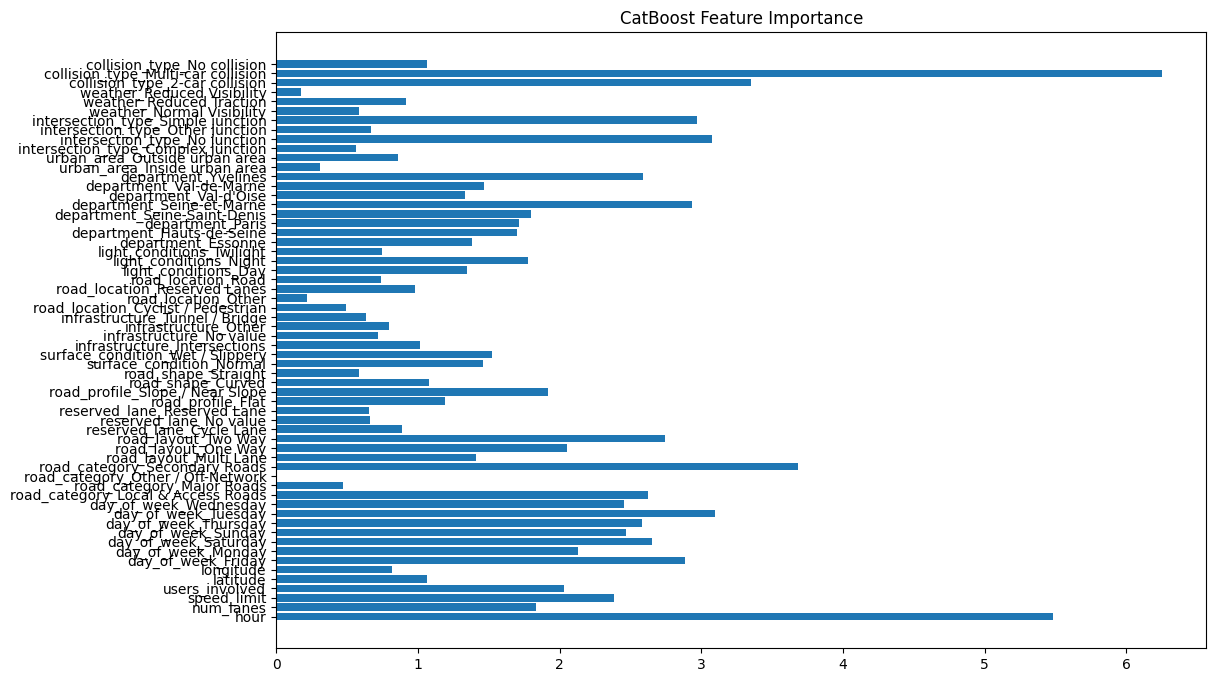

In [375]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE works only with numeric features, so we need to encode categoricals temporarily
X_train_num = X_train.copy()
X_test_num = X_test.copy()

# Convert categorical columns to dummy variables for SMOTE
X_train_num = pd.get_dummies(X_train_num, columns=[X_train.columns[i] for i in cat_features], drop_first=False)
X_test_num = pd.get_dummies(X_test_num, columns=[X_test.columns[i] for i in cat_features], drop_first=False)

# Align columns (in case some categories are missing in test)
X_test_num = X_test_num.reindex(columns=X_train_num.columns, fill_value=0)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_num, y_train)

# Train CatBoost on oversampled data
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=True
)

model.fit(X_train_res, y_train_res)

# Feature importance
importances = model.get_feature_importance()
feature_names = X_train_res.columns

# Print top 20
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{name}: {imp:.3f}")

# Plot
plt.figure(figsize=(12,8))
plt.barh(feature_names, importances)
plt.title("CatBoost Feature Importance")
plt.show()

## Train on top 20 columns as baseline

In [376]:
# Combine feature names and importances
feat_imp_df = pd.DataFrame({
    "feature": X_train_res.columns,
    "importance": importances
})

# Sort descending and select top 20
top_features = feat_imp_df.sort_values("importance", ascending=False).head(20)["feature"].tolist()

print("Top 20 features:")
print(top_features)

Top 20 features:
['collision_type_Multi-car collision', 'hour', 'road_category_Secondary Roads', 'collision_type_2-car collision', 'day_of_week_Tuesday', 'intersection_type_No junction', 'intersection_type_Simple junction', 'department_Seine-et-Marne', 'day_of_week_Friday', 'road_layout_Two Way', 'day_of_week_Saturday', 'road_category_Local & Access Roads', 'department_Yvelines', 'day_of_week_Thursday', 'day_of_week_Sunday', 'day_of_week_Wednesday', 'speed_limit', 'day_of_week_Monday', 'road_layout_One Way', 'users_involved']


In [377]:
# Need to remove collision type and users involved as we won't know this
# information prior to an accident
top_features = ['hour', 'road_category_Secondary Roads', 'day_of_week_Tuesday',
                'intersection_type_No junction', 'intersection_type_Simple junction',
                'department_Seine-et-Marne', 'day_of_week_Friday', 'road_layout_Two Way',
                'day_of_week_Saturday', 'road_category_Local & Access Roads',
                'department_Yvelines', 'day_of_week_Thursday', 'day_of_week_Sunday',
                'day_of_week_Wednesday', 'speed_limit', 'day_of_week_Monday',
                'road_layout_One Way']

In [378]:
X_train_top = X_train_res[top_features]
X_test_top = X_test_num[top_features]

In [379]:
top20 = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=True
)

top20.fit(X_train_top, y_train_res)

0:	learn: 1.0681559	total: 24.2ms	remaining: 12.1s
1:	learn: 1.0340233	total: 36.4ms	remaining: 9.06s
2:	learn: 1.0106577	total: 48ms	remaining: 7.95s
3:	learn: 0.9879661	total: 60.5ms	remaining: 7.5s
4:	learn: 0.9664696	total: 69.1ms	remaining: 6.84s
5:	learn: 0.9486801	total: 77ms	remaining: 6.34s
6:	learn: 0.9312109	total: 84.7ms	remaining: 5.97s
7:	learn: 0.9147686	total: 94.1ms	remaining: 5.79s
8:	learn: 0.9009472	total: 102ms	remaining: 5.58s
9:	learn: 0.8874166	total: 110ms	remaining: 5.37s
10:	learn: 0.8743666	total: 117ms	remaining: 5.21s
11:	learn: 0.8625808	total: 125ms	remaining: 5.09s
12:	learn: 0.8508971	total: 134ms	remaining: 5.01s
13:	learn: 0.8407617	total: 142ms	remaining: 4.92s
14:	learn: 0.8280004	total: 150ms	remaining: 4.83s
15:	learn: 0.8188480	total: 157ms	remaining: 4.74s
16:	learn: 0.8035728	total: 164ms	remaining: 4.67s
17:	learn: 0.7950659	total: 172ms	remaining: 4.6s
18:	learn: 0.7815572	total: 180ms	remaining: 4.56s
19:	learn: 0.7736844	total: 191ms	remai

In [380]:
y_pred = top20.predict(X_test_top)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.06      0.02      0.03        48
           3       0.33      0.14      0.20       373
           4       0.91      0.97      0.94      3579

    accuracy                           0.88      4000
   macro avg       0.43      0.38      0.39      4000
weighted avg       0.84      0.88      0.86      4000



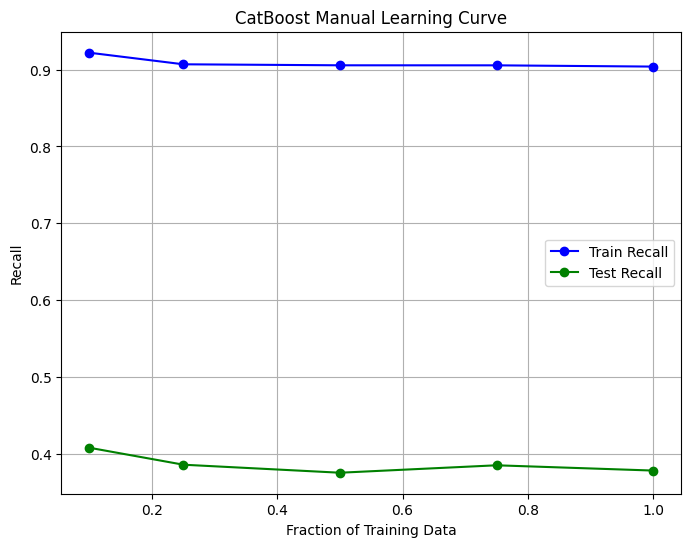

In [381]:
# Define fractions of training data to use
train_fracs = [0.1, 0.25, 0.5, 0.75, 1.0]

train_scores = []
test_scores = []

for frac in train_fracs:
    # Sample fraction of training data
    X_frac = X_train_top.sample(frac=frac, random_state=42)
    y_frac = y_train_res.loc[X_frac.index]

    # Initialize CatBoost model
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        verbose=0  # suppress output
    )

    # Fit on subset
    model.fit(X_frac, y_frac)

    # Predict on training subset
    y_train_pred = model.predict(X_frac)
    train_recall = recall_score(y_frac, y_train_pred, average='macro')
    train_scores.append(train_recall)

    # Predict on full test set
    y_test_pred = model.predict(X_test_top)
    test_recall = recall_score(y_test, y_test_pred, average='macro')
    test_scores.append(test_recall)

# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_fracs, train_scores, 'o-', color='blue', label='Train Recall')
plt.plot(train_fracs, test_scores, 'o-', color='green', label='Test Recall')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Recall')
plt.title('CatBoost Manual Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

## Feature Engineering

In [382]:
# FEATURE ENGINEERING: RUSH HOUR & DAY OF WEEK

day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
    "Friday": 4, "Saturday": 5, "Sunday": 6
}
if df['day_of_week'].dtype == object:
    df['day_of_week_num'] = df['day_of_week'].map(day_map)
else:
    df['day_of_week_num'] = df['day_of_week']

# Conditions
conds = [
    # Weekday rush hours
    ((df['day_of_week_num'] >= 0) & (df['day_of_week_num'] <= 4) &
     (((df['hour'] >= 7) & (df['hour'] <= 10)) | ((df['hour'] >= 16) & (df['hour'] <= 19)))),

    # Weekday off-peak
    ((df['day_of_week_num'] >= 0) & (df['day_of_week_num'] <= 4) &
     ~(((df['hour'] >= 7) & (df['hour'] <= 10)) | ((df['hour'] >= 16) & (df['hour'] <= 19)))),

    # Weekend off-peak
    ((df['day_of_week_num'] >= 5) & (df['day_of_week_num'] <= 6))
]

choices = [
    'weekday_rush_hour',
    'weekday_off_peak',
    'weekend_off_peak'
]

df['time_category'] = np.select(conds, choices, default='unknown')

In [383]:
# Road category encoding

# Define mapping
road_category_map = {
    'Local & Access Roads': 0,
    'Secondary Roads': 1,
    'Major Roads': 2,
    'Other / Off-Network': 0
}

# Apply mapping
df['road_category_encoded'] = df['road_category'].map(road_category_map)

In [384]:
# Road layout encoding

# Define mapping
road_layout_map = {
    'One Way': 0,
    'Two Way': 1,
    'Multi Lane': 2,
}

# Apply mapping
df['road_layout_encoded'] = df['road_layout'].map(road_layout_map)

In [385]:
# Intersection encoding

# Define mapping
intersection_map = {
    'No junction': 0,
    'Simple junction': 1,
    'Other junction': 2,
    'Complex junction': 2,
}

# Apply mapping
df['intersection_encoded'] = df['intersection_type'].map(intersection_map)

In [386]:
# Road shape encoding

# Define mapping
road_shape_map = {
    'Straight': 0,
    'Curved': 1,
}

# Apply mapping
df['road_shape_encoded'] = df['road_shape'].map(road_shape_map)

In [387]:
# Road profile encoding

# Define mapping
road_profile_map = {
    'Flat': 0,
    'Slope / Near Slope': 1,
}

# Apply mapping
df['road_profile_encoded'] = df['road_profile'].map(road_profile_map)

In [388]:
# Lighting encoding

# Define mapping
lighting_map = {
    'Day': 0,
    'Twilight': 1,
    'Night': 2
}

# Apply mapping
df['lighting_encoded'] = df['light_conditions'].map(lighting_map)

In [389]:
# Surface condition encoding

# Define mapping
surface_map = {
    'Normal': 0,
    'Wet / Slippery': 1
}

# Apply mapping
df['surface_encoded'] = df['surface_condition'].map(surface_map)

In [390]:
# Normalize speed
df['speed_limit_norm'] = (df['speed_limit'] - df['speed_limit'].min()) / (df['speed_limit'].max() - df['speed_limit'].min())

In [391]:
# Composite risk column
df['road_risk_score'] = (
    df['road_layout_encoded'] * 1.0 +
    df['intersection_encoded'] * 1.0 +
    df['road_category_encoded'] * 0.5 +
    df['lighting_encoded'] * 0.5 +
    df['surface_encoded'] * 1.0 +
    df['speed_limit_norm'] * 2 +
    df['road_profile_encoded'] * 0.5 +
    df['road_shape_encoded'] * 0.5
)

In [392]:
# Normalize road risk
df['road_risk_norm'] = (df['road_risk_score'] - df['road_risk_score'].min()) / (df['road_risk_score'].max() - df['road_risk_score'].min())

In [393]:
# High-speed curve
df['high_speed_curved'] = ((df['road_shape_encoded'] == 2) & (df['speed_limit_norm'] > 0.7)).astype(int)

# Complex intersection
df['complex_intersection'] = (df['intersection_encoded'] == 3).astype(int)

# Poor lighting + slippery
df['poor_light_slippery'] = ((df['lighting_encoded'] >= 2) & (df['surface_encoded'] == 2)).astype(int)

# High speed + slippery
df['high_speed_slippery'] = ((df['speed_limit_norm'] > 0.7) & (df['surface_encoded'] == 2)).astype(int)

## Model after feature engineering

### With encoded road columns

In [394]:
# Define X and y

target = "injury_severity"

y = df["injury_severity"]
X = df[['department', 'time_category', 'speed_limit_norm', 'road_category',
        'road_layout', 'intersection_type', 'light_conditions',
        'surface_condition', 'road_risk_norm'
       ]]

# , 'poor_light_slippery' 'road_shape_encoded', 'road_profile_encoded',

# Detect categorical columns automatically
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

0:	learn: 1.0731109	total: 21.9ms	remaining: 6.54s
1:	learn: 1.0518842	total: 35.1ms	remaining: 5.23s
2:	learn: 1.0343277	total: 44.8ms	remaining: 4.44s
3:	learn: 1.0142899	total: 54.5ms	remaining: 4.03s
4:	learn: 0.9996239	total: 65.2ms	remaining: 3.84s
5:	learn: 0.9869211	total: 74.3ms	remaining: 3.64s
6:	learn: 0.9728586	total: 83.4ms	remaining: 3.49s
7:	learn: 0.9576452	total: 92.9ms	remaining: 3.39s
8:	learn: 0.9453126	total: 102ms	remaining: 3.31s
9:	learn: 0.9342797	total: 112ms	remaining: 3.26s
10:	learn: 0.9209376	total: 122ms	remaining: 3.19s
11:	learn: 0.9112106	total: 134ms	remaining: 3.2s
12:	learn: 0.9016119	total: 142ms	remaining: 3.14s
13:	learn: 0.8918987	total: 151ms	remaining: 3.08s
14:	learn: 0.8857067	total: 159ms	remaining: 3.02s
15:	learn: 0.8747875	total: 168ms	remaining: 2.99s
16:	learn: 0.8672430	total: 177ms	remaining: 2.95s
17:	learn: 0.8611989	total: 186ms	remaining: 2.91s
18:	learn: 0.8536050	total: 195ms	remaining: 2.88s
19:	learn: 0.8448900	total: 204ms	

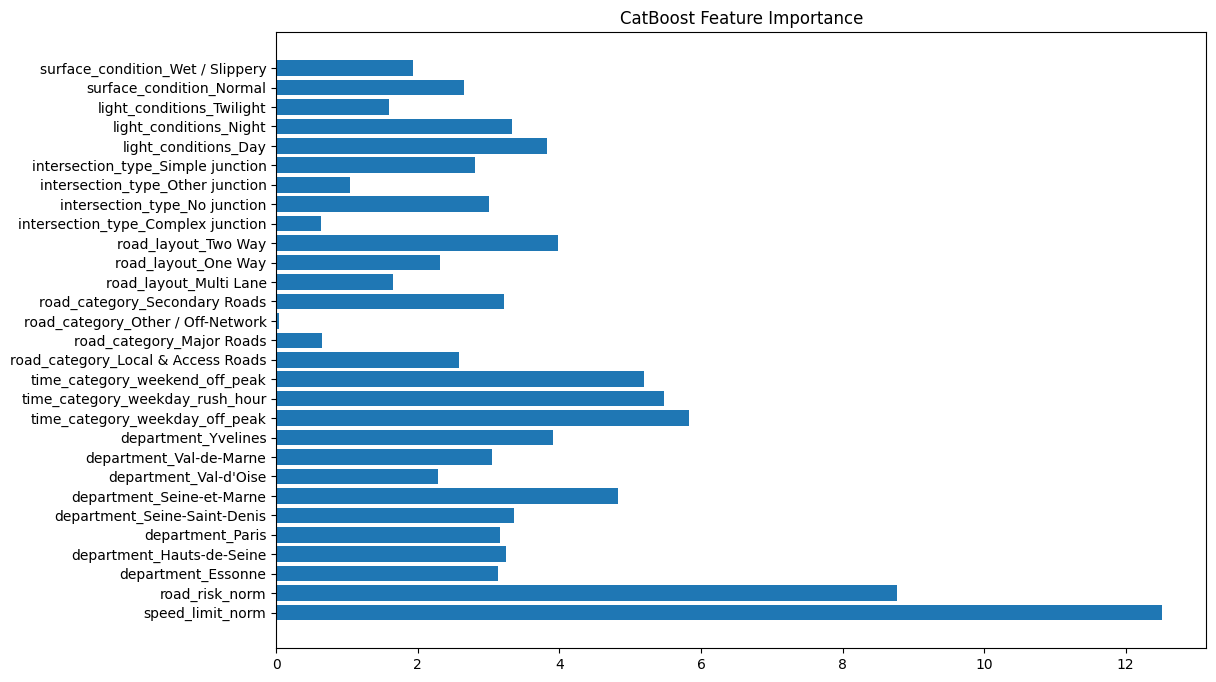

In [395]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE works only with numeric features, so we need to encode categoricals temporarily
X_train_num = X_train.copy()
X_test_num = X_test.copy()

# Convert categorical columns to dummy variables for SMOTE
X_train_num = pd.get_dummies(X_train_num, columns=[X_train.columns[i] for i in cat_features], drop_first=False)
X_test_num = pd.get_dummies(X_test_num, columns=[X_test.columns[i] for i in cat_features], drop_first=False)

# Align columns (in case some categories are missing in test)
X_test_num = X_test_num.reindex(columns=X_train_num.columns, fill_value=0)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_num, y_train)

# Train CatBoost on oversampled data
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=True
)

model.fit(X_train_res, y_train_res)

# Feature importance
importances = model.get_feature_importance()
feature_names = X_train_res.columns

# Print top 20
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{name}: {imp:.3f}")

# Plot
plt.figure(figsize=(12,8))
plt.barh(feature_names, importances)
plt.title("CatBoost Feature Importance")
plt.show()

In [396]:
# Combine feature names and importances
feat_imp_df = pd.DataFrame({
    "feature": X_train_res.columns,
    "importance": importances
})

# Sort descending and select top 20
top_features = feat_imp_df.sort_values("importance", ascending=False).head(20)["feature"].tolist()

print("Top 20 features:")
print(top_features)

Top 20 features:
['speed_limit_norm', 'road_risk_norm', 'time_category_weekday_off_peak', 'time_category_weekday_rush_hour', 'time_category_weekend_off_peak', 'department_Seine-et-Marne', 'road_layout_Two Way', 'department_Yvelines', 'light_conditions_Day', 'department_Seine-Saint-Denis', 'light_conditions_Night', 'department_Hauts-de-Seine', 'road_category_Secondary Roads', 'department_Paris', 'department_Essonne', 'department_Val-de-Marne', 'intersection_type_No junction', 'intersection_type_Simple junction', 'surface_condition_Normal', 'road_category_Local & Access Roads']


In [397]:
X_train_top = X_train_res[top_features]
X_test_top = X_test_num[top_features]

In [398]:
encoded = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=True
)

encoded.fit(X_train_top, y_train_res)

0:	learn: 1.0724534	total: 25ms	remaining: 12.5s
1:	learn: 1.0519809	total: 41.9ms	remaining: 10.4s
2:	learn: 1.0330920	total: 49.8ms	remaining: 8.24s
3:	learn: 1.0175900	total: 58.1ms	remaining: 7.21s
4:	learn: 0.9994440	total: 66.5ms	remaining: 6.58s
5:	learn: 0.9868116	total: 75.3ms	remaining: 6.2s
6:	learn: 0.9720538	total: 83.8ms	remaining: 5.91s
7:	learn: 0.9580371	total: 94.1ms	remaining: 5.79s
8:	learn: 0.9465352	total: 104ms	remaining: 5.65s
9:	learn: 0.9349488	total: 113ms	remaining: 5.53s
10:	learn: 0.9258664	total: 122ms	remaining: 5.4s
11:	learn: 0.9138751	total: 130ms	remaining: 5.27s
12:	learn: 0.9022297	total: 139ms	remaining: 5.19s
13:	learn: 0.8947869	total: 146ms	remaining: 5.07s
14:	learn: 0.8868004	total: 155ms	remaining: 5.02s
15:	learn: 0.8790317	total: 163ms	remaining: 4.94s
16:	learn: 0.8698380	total: 171ms	remaining: 4.86s
17:	learn: 0.8635111	total: 179ms	remaining: 4.8s
18:	learn: 0.8558316	total: 188ms	remaining: 4.75s
19:	learn: 0.8496934	total: 197ms	rema

In [399]:
y_pred = encoded.predict(X_test_top)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.06      0.06      0.06        48
           3       0.22      0.24      0.23       373
           4       0.91      0.90      0.91      3579

    accuracy                           0.83      4000
   macro avg       0.40      0.40      0.40      4000
weighted avg       0.84      0.83      0.83      4000



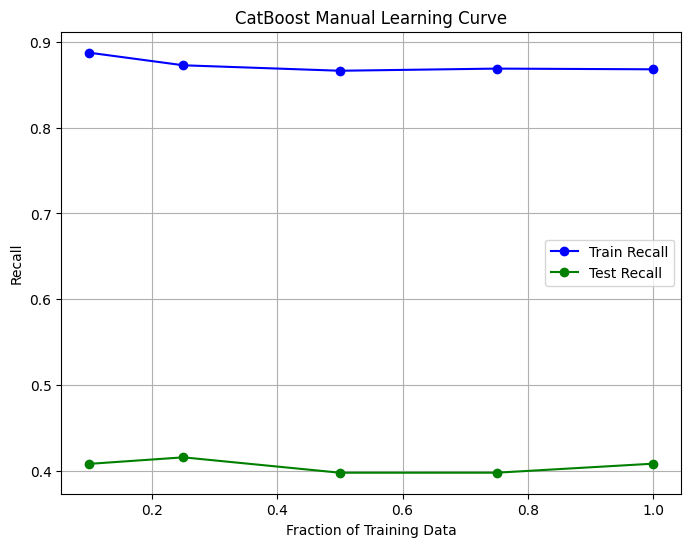

In [401]:
# Define fractions of training data to use
train_fracs = [0.1, 0.25, 0.5, 0.75, 1.0]

train_scores = []
test_scores = []

for frac in train_fracs:
    # Sample fraction of training data
    X_frac = X_train_top.sample(frac=frac, random_state=42)
    y_frac = y_train_res.loc[X_frac.index]

    # Initialize CatBoost model
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        verbose=0  # suppress output
    )

    # Fit on subset
    model.fit(X_frac, y_frac)

    # Predict on training subset
    y_train_pred = model.predict(X_frac)
    train_recall = recall_score(y_frac, y_train_pred, average='macro')
    train_scores.append(train_recall)

    # Predict on full test set
    y_test_pred = model.predict(X_test_top)
    test_recall = recall_score(y_test, y_test_pred, average='macro')
    test_scores.append(test_recall)

# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_fracs, train_scores, 'o-', color='blue', label='Train Recall')
plt.plot(train_fracs, test_scores, 'o-', color='green', label='Test Recall')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Recall')
plt.title('CatBoost Manual Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
params = {
    'iterations': randint(100, 1000),
    'depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'l2_leaf_reg': uniform(1, 10),
    'border_count': randint(32, 255)
}

search_cat = RandomizedSearchCV(
    encoded,
    params,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search_cat.fit(X_train_top, y_train_res)
search_cat.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0:	learn: 1.0460683	total: 241ms	remaining: 3m 51s
1:	learn: 1.0083898	total: 280ms	remaining: 2m 14s
0:	learn: 1.0452612	total: 294ms	remaining: 4m 41s
2:	learn: 0.9750570	total: 319ms	remaining: 1m 41s
1:	learn: 1.0060427	total: 356ms	remaining: 2m 50s
3:	learn: 0.9492838	total: 365ms	remaining: 1m 27s
2:	learn: 0.9709849	total: 425ms	remaining: 2m 15s
4:	learn: 0.9294532	total: 440ms	remaining: 1m 24s
0:	learn: 1.0443653	total: 434ms	remaining: 6m 56s
0:	learn: 1.0382415	total: 487ms	remaining: 7m 47s
0:	learn: 1.0437034	total: 489ms	remaining: 7m 49s
0:	learn: 1.0876039	total: 535ms	remaining: 1m 57s
0:	learn: 1.0875329	total: 557ms	remaining: 2m 2s
0:	learn: 1.0868244	total: 558ms	remaining: 2m 2s
1:	learn: 1.0091560	total: 550ms	remaining: 4m 23s
3:	learn: 0.9336203	total: 592ms	remaining: 2m 21s
1:	learn: 1.0086459	total: 569ms	remaining: 4m 32s
5:	learn: 0.8935027	total: 596ms	remaining: 1m 34s
1:	learn: 1.0035673	to

{'border_count': 203,
 'depth': 9,
 'iterations': 926,
 'l2_leaf_reg': np.float64(4.232029320207552),
 'learning_rate': np.float64(0.16563718652300982)}

In [361]:
best_cat = search_cat.best_estimator_

cv_results_cat = cross_val_score(best_cat, X_train_top, y_train_res, cv=5, scoring='f1_macro').mean()
cv_results_cat

0:	learn: 1.0362759	total: 44.3ms	remaining: 41s
1:	learn: 0.9890505	total: 78ms	remaining: 36s
2:	learn: 0.9499738	total: 110ms	remaining: 33.9s
3:	learn: 0.9147346	total: 138ms	remaining: 31.8s
4:	learn: 0.8867779	total: 169ms	remaining: 31.2s
5:	learn: 0.8575630	total: 197ms	remaining: 30.2s
6:	learn: 0.8336388	total: 229ms	remaining: 30.1s
7:	learn: 0.8084366	total: 260ms	remaining: 29.9s
8:	learn: 0.7897338	total: 291ms	remaining: 29.6s
9:	learn: 0.7712880	total: 322ms	remaining: 29.5s
10:	learn: 0.7562179	total: 352ms	remaining: 29.3s
11:	learn: 0.7388862	total: 381ms	remaining: 29s
12:	learn: 0.7197391	total: 409ms	remaining: 28.8s
13:	learn: 0.7061631	total: 438ms	remaining: 28.5s
14:	learn: 0.6955285	total: 466ms	remaining: 28.3s
15:	learn: 0.6851849	total: 496ms	remaining: 28.2s
16:	learn: 0.6729815	total: 524ms	remaining: 28s
17:	learn: 0.6606481	total: 552ms	remaining: 27.8s
18:	learn: 0.6485635	total: 580ms	remaining: 27.7s
19:	learn: 0.6375728	total: 607ms	remaining: 27.5

np.float64(0.8908696885431915)